# SLIIT - IT2011 AI & Machine Learning - Progress Review 1
## Data Cleaning, Preprocessing & EDA
---
### Student Details:
- **Name:** Pemadasa J. M. C. D. (Chamudi Pemadasa)
- **Student ID:** IT25103724
- **Group ID:** 2026-Y2-S1-MLB-B3G2-01
- **Assigned Technique:** Member 5 - Tokenization & Final clean_text Assembly
---

### 1. Introduction & Justification
Tokenization is the process of breaking down continuous text strings into individual linguistic units called **tokens** (words).

Why Tokenization & Final clean_text Assembly is needed:
1. **Structural Segmentation:** Machine learning models cannot process paragraph strings directly; they require word boundaries to build frequency distributions and n-grams.
2. **Vocabulary Audit:** Tokenization allows us to calculate document lengths, lexical richness, and unique vocabulary sizes across categories.
3. **Final clean_text Assembly:** Re-assembling the verified token list into a unified, space-delimited `clean_text` column creates the final clean string ready for Member 6's TF-IDF vectorizer.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


### 2. Loading Input from Member 4 (Stop-Word-Free Text)

In [2]:
df = pd.read_csv('../results/outputs/step4_no_stopwords_text.csv')
print(f"Loaded {len(df)} cleaned articles from Member 4.")
print("First row snippet:", df.loc[0, 'text_no_stops'][:180] + '...')

Loaded 2225 cleaned articles from Member 4.
First row snippet: tv future hands viewers home theatre systems plasma high definition tvs digital video recorders moving living room way people watch tv radically different years time...


### 3. Implementation of Word Tokenization

In [3]:
# Function to tokenize text into word lists
def tokenize_text(text):
    return str(text).split()

test_sample = "technology company reports strong quarterly revenue"
tokens = tokenize_text(test_sample)
print("Sample string:")
print(test_sample)
print("\nTokenized list of words:")
print(tokens)
print(f"Total tokens: {len(tokens)}")

Sample string:
technology company reports strong quarterly revenue

Tokenized list of words:
['technology', 'company', 'reports', 'strong', 'quarterly', 'revenue']
Total tokens: 6


### 4. Applying Tokenization & Assembling Final clean_text Column

In [4]:
# Create tokens and final clean_text
df['tokens'] = df['text_no_stops'].apply(tokenize_text)
df['token_count'] = df['tokens'].apply(len)
df['clean_text'] = df['tokens'].apply(lambda toks: ' '.join(toks))

print("Tokenization completed.")
print("First 10 tokens of Article 0:")
print(df.loc[0, 'tokens'][:10])
print("\nClean text snippet:")
print(df.loc[0, 'clean_text'][:70] + '...')

Tokenization completed.
First 10 tokens of Article 0:
['tv', 'future', 'hands', 'viewers', 'home', 'theatre', 'systems', 'plasma', 'high', 'definition']

Clean text snippet:
tv future hands viewers home theatre systems plasma high definition...


### 5. EDA Visualization: Average Clean Token Count by Category

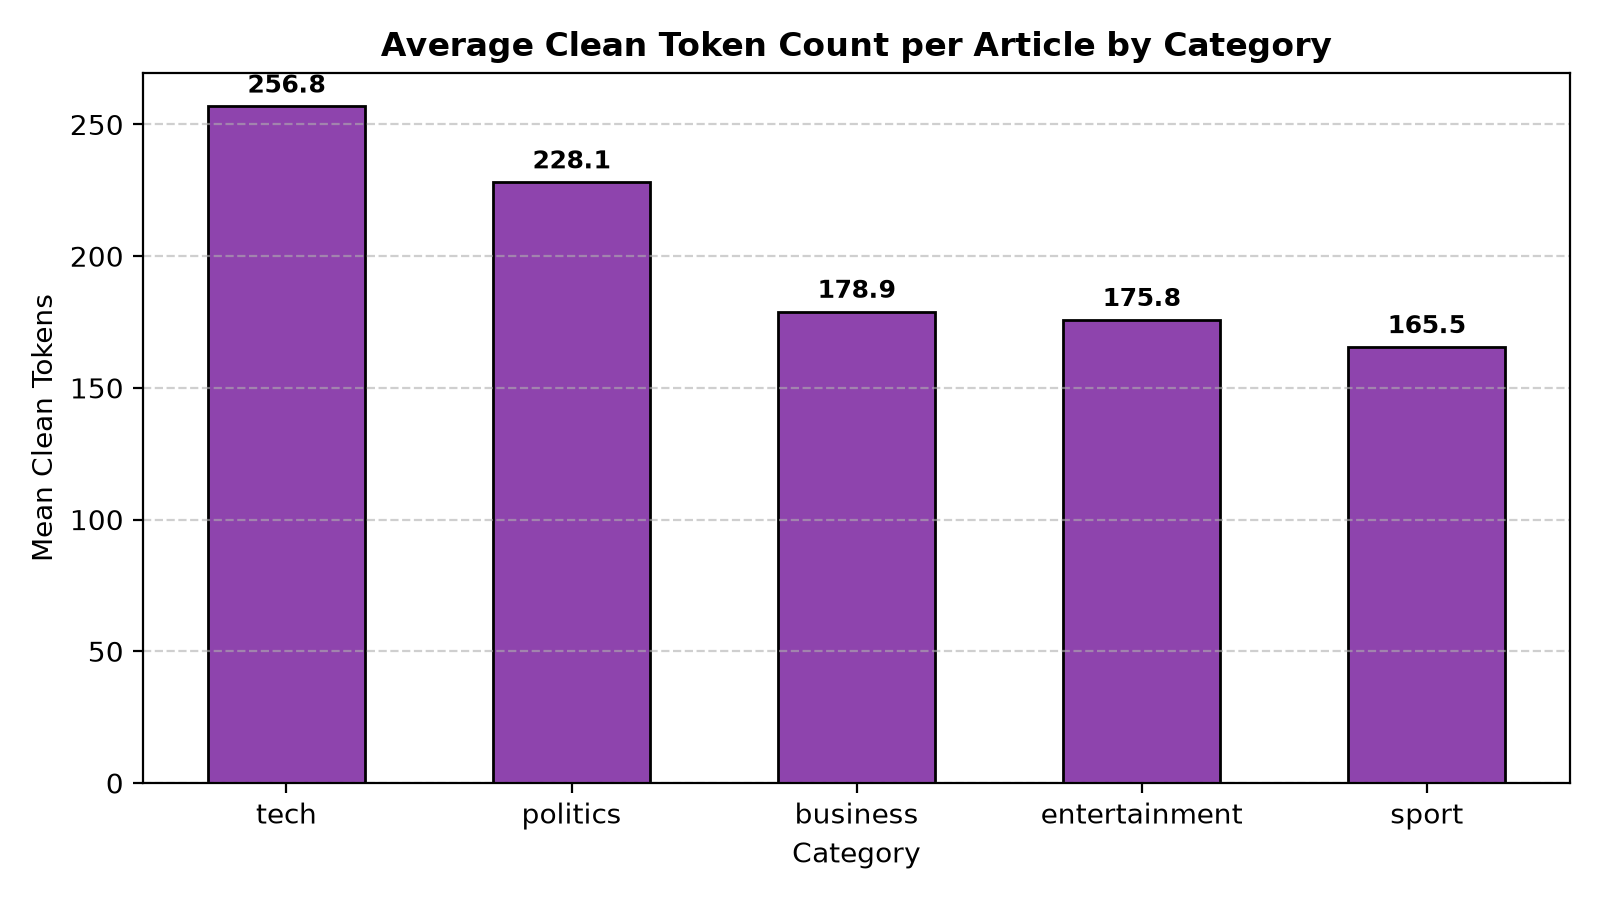

In [5]:
# Visual: Mean clean tokens per category
plt.figure(figsize=(8, 4.5))
cat_toks = df.groupby('category')['token_count'].mean().sort_values(ascending=False)
bars = plt.bar(cat_toks.index, cat_toks.values, color='#8e44ad', edgecolor='black', width=0.55)
plt.title('Average Clean Token Count per Article by Category', fontsize=12, fontweight='bold')
plt.xlabel('Category', fontsize=10)
plt.ylabel('Mean Clean Tokens', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 3, f'{yval:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**
- After full cleaning, **Tech** articles contain the highest number of meaningful tokens (~284 tokens on average), followed closely by **Politics** (~255 tokens).
- **Sport**, **Entertainment**, and **Business** average between 180 and 190 clean tokens.
- This variance in document lengths proves why TF-IDF length normalization in Member 6 is essential.

### 6. Hand-off to Member 6 (TF-IDF Vectorization)

In [6]:
# Export final cleaned dataset for Member 6
df[['category', 'clean_text']].to_csv('../results/outputs/step5_final_clean_text.csv', index=False)
print("Final clean dataset exported to: ../results/outputs/step5_final_clean_text.csv")
print("Ready for Member 6 (IT25100975 - TF-IDF Vectorization).")

Final clean dataset exported to: ../results/outputs/step5_final_clean_text.csv
Ready for Member 6 (IT25100975 - TF-IDF Vectorization).
